**Takeaways:**
1. Our map is in line and in fact is even better because we are specifically showing Copper, Cable and Fiber. In the FCC map, a lot of values are 100% because of satellite coverage. We might want to keep that data (we will have to download files separately but integrating rest of the steps: extraction, processing should be fairly straight-forward)

2. Intuitively, these features (speeds_tech_x_y) should have high weights in our overall index 

In [2]:
# ── Cell 1: Imports & paths
import pandas as pd
import plotly.express as px
from pathlib import Path
import pygris
import json

TRACT_DIR = Path("/home/eprashar_solutions_corelogic_com/network-idx/data/features/fcc/broadband_coverage/tract")

In [4]:
# ── Cell 2: Load all tract parquets

tract_files = sorted(TRACT_DIR.glob("fcc_coverage_tract_??_??.parquet"))
print(f"Tract parquets found: {len(tract_files)}")

dfs = [pd.read_parquet(f) for f in tract_files]
tracts = pd.concat(dfs, ignore_index=True)
print(f"Total tracts: {len(tracts):,}")
tracts.head()

Tract parquets found: 51
Total tracts: 85,189


,tract_geoid,state_fips,state_usps,estimated_census_housing_units,estimated_fcc_units,copper_speed_100_20,copper_less_than_100_20,copper_more_than_100_20,cable_speed_100_20,cable_less_than_100_20,cable_more_than_100_20,fiber_speed_100_20,fiber_less_than_100_20,fiber_more_than_100_20
0,02013000100,02,AK,676,1164,0.0000,0.5126,0.0,0.0000,0.0000,0.0000,0.7208,0.7208,0.7208
1,02016000100,02,AK,556,924,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.2208,0.0000
2,02016000200,02,AK,774,653,0.0000,0.0000,0.0,0.0000,0.7416,0.0000,0.9450,0.9450,0.9450
3,02020000101,02,AK,2178,2453,0.0198,0.6738,0.0,0.9594,0.9594,0.9594,0.0502,0.0641,0.0487
4,02020000102,02,AK,2227,2510,0.0198,0.6738,0.0,0.9594,0.9594,0.9594,0.0502,0.0641,0.0487


In [5]:
# ── Cell 3: Tier classification

TECHS_100_20 = ["fiber_speed_100_20", "cable_speed_100_20", "copper_speed_100_20"]

tracts["fiber_100_20"] = tracts["fiber_speed_100_20"]
tracts["any_tech_100_20"] = tracts[TECHS_100_20].max(axis=1)

def classify_tier(row):
    fiber = row["fiber_100_20"]
    any_tech = row["any_tech_100_20"]

    if fiber >= 0.80:
        return "A: Fiber ≥80%"
    if any_tech >= 0.80:
        return "B: Any tech ≥80%"
    if fiber >= 0.60:
        return "C: Fiber 60–80%"
    if any_tech >= 0.60:
        return "D: Any tech 60–80%"
    if fiber >= 0.40:
        return "E: Fiber 40–60%"
    if any_tech >= 0.40:
        return "F: Any tech 40–60%"
    return "G: Underserved (<40%)"

tracts["tier"] = tracts.apply(classify_tier, axis=1)
print(tracts["tier"].value_counts().sort_index())

tier
A: Fiber ≥80%            14783
B: Any tech ≥80%         51933
C: Fiber 60–80%           4133
D: Any tech 60–80%        6850
E: Fiber 40–60%           2258
F: Any tech 40–60%        1883
G: Underserved (<40%)     3349
Name: count, dtype: int64


In [6]:
# Downloads 2020 TIGER/Line tract shapefile for all states (cached after first call)
tract_shapes = pygris.tracts(year=2020, cb=True)  # cb=True = cartographic boundary (smaller/faster)

print(f"Tract polygons: {len(tract_shapes):,}")
print("Columns:", list(tract_shapes.columns))
print("Sample GEOID:", tract_shapes["GEOID"].iloc[0])

Retrieving Census tracts for the entire United States
Tract polygons: 85,187
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'AFFGEOID', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']
Sample GEOID: 06077003406


In [7]:
# ── Cell 5: Merge data with geometries

# Merge tract data onto shapes
merged = tract_shapes.merge(tracts, left_on="GEOID", right_on="tract_geoid", how="inner")
print(f"Matched tracts: {len(merged):,} / {len(tracts):,}")

merged["geometry"] = merged["geometry"].simplify(tolerance=0.01, preserve_topology=True)
merged_json = json.loads(merged.to_json())

Matched tracts: 84,855 / 85,189


/tmp/ipykernel_3758340/467076639.py:15: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  merged.plot(


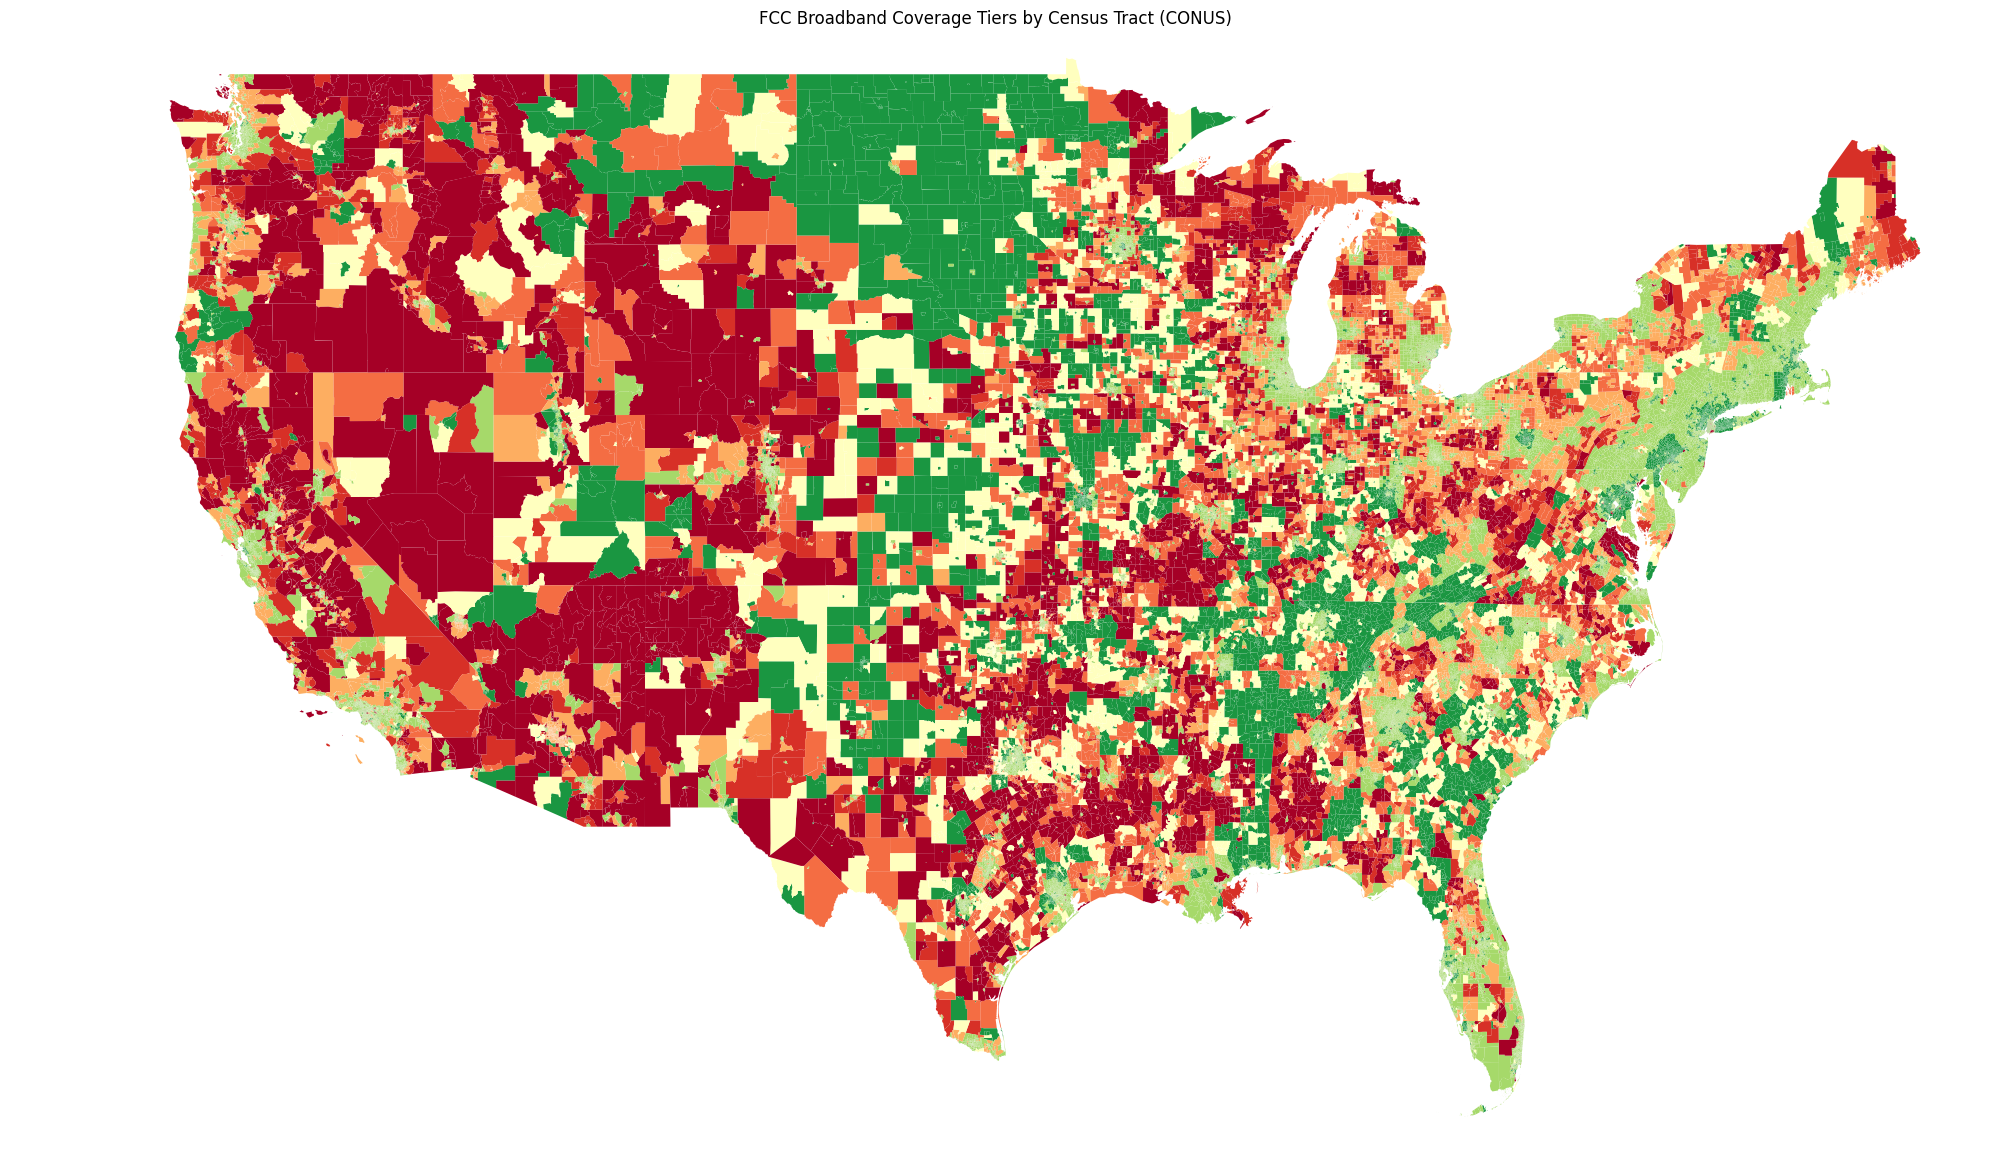

In [20]:
import matplotlib.pyplot as plt

TIER_COLORS = {
    "A: Fiber ≥80%": "#1a9641",
    "B: Any tech ≥80%": "#a6d96a",
    "C: Fiber 60–80%": "#ffffbf",
    "D: Any tech 60–80%": "#fdae61",
    "E: Fiber 40–60%": "#f46d43",
    "F: Any tech 40–60%": "#d73027",
    "G: Underserved (<40%)": "#a50026",
}


fig, ax = plt.subplots(1, 1, figsize=(20, 12))
merged.plot(
    column="tier",
    categorical=True,
    color=merged["tier"].map(TIER_COLORS),
    legend=True,
    ax=ax,
    linewidth=0,
)
ax.set_xlim(-130, -65)
ax.set_ylim(24, 50)
ax.set_axis_off()
ax.set_title("FCC Broadband Coverage Tiers by Census Tract (CONUS)")
plt.tight_layout()
plt.show()

In [9]:
# TODO: produce county-level using processed data and compare with FCC website map 
# County-level choropleth

COUNTY_DIR = Path("/home/eprashar_solutions_corelogic_com/network-idx/data/processed/fcc/broadband_coverage")

county_files = sorted(COUNTY_DIR.glob("fcc_fixed_coverage_county_??_??.parquet"))
print(f"County parquets found: {len(county_files)}")

# Store county-level dataframes in a list
dfs_c = [pd.read_parquet(f) for f in county_files]

# Concatenate all county dataframes into one
counties = pd.concat(dfs_c, ignore_index=True)
print(f"Total counties: {len(counties):,}")

# Tier classification (same logic as tracts)
counties["fiber_100_20"] = counties["fiber_speed_100_20"]
counties["any_tech_100_20"] = counties[TECHS_100_20].max(axis=1)
counties["tier"] = counties.apply(classify_tier, axis=1)
print(counties["tier"].value_counts().sort_index())

County parquets found: 56
Total counties: 3,232
tier
A: Fiber ≥80%            663
B: Any tech ≥80%         636
C: Fiber 60–80%          551
D: Any tech 60–80%       467
E: Fiber 40–60%          354
F: Any tech 40–60%       230
G: Underserved (<40%)    331
Name: count, dtype: int64


In [17]:
# Check for specific counties
county_ids = ["72007","72013"]
print(counties[counties["geography_id"].isin(county_ids)])

     geography_id          geography_desc         geography_desc_full  \
2323        72007  Aguas Buenas Municipio  Aguas Buenas Municipio, PR   
2326        72013       Arecibo Municipio       Arecibo Municipio, PR   

      total_units  copper_speed_100_20  copper_less_than_100_20  \
2323         8075                  0.0                 0.290526   
2326        37557                  0.0                 0.390846   

      copper_more_than_100_20  cable_speed_100_20  cable_less_than_100_20  \
2323                      0.0            0.590836                0.590836   
2326                      0.0            0.908912                0.908912   

      cable_more_than_100_20  fiber_speed_100_20  fiber_less_than_100_20  \
2323                0.590836            0.753932                0.753932   
2326                0.908912            0.876721                0.876721   

      fiber_more_than_100_20  fiber_100_20  any_tech_100_20             tier  
2323                0.753932      0.75

In [10]:
# What county GEOIDs does FCC have for Connecticut (FIPS 09)?
ct_counties = counties[counties["geography_id"].str.startswith("09")]["geography_id"].tolist()
print("FCC CT county GEOIDs:", ct_counties)

# 2020 vintage: 09001, 09003, 09005, 09007, 09009, 09011, 09013, 09015 (8 counties)
# 2022+ vintage: 09110, 09120, 09130, 09140, 09150, 09160, 09170, 09180, 09190 (9 planning regions)

FCC CT county GEOIDs: ['09001', '09003', '09005', '09007', '09009', '09011', '09013', '09015']


In [11]:
# County boundaries from pygris
county_shapes = pygris.counties(year=2020, cb=True)
print(f"County polygons: {len(county_shapes):,}")

# Merge
counties_merged = county_shapes.merge(counties, left_on="GEOID", right_on="geography_id", how="inner")
print(f"Matched counties: {len(counties_merged):,} / {len(counties):,}")

# Simplify (lighter tolerance — fewer polygons so less needed)
counties_merged["geometry"] = counties_merged["geometry"].simplify(tolerance=0.01, preserve_topology=True)



County polygons: 3,234
Matched counties: 3,232 / 3,232


/tmp/ipykernel_3758340/1114560203.py:3: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  counties_merged.plot(


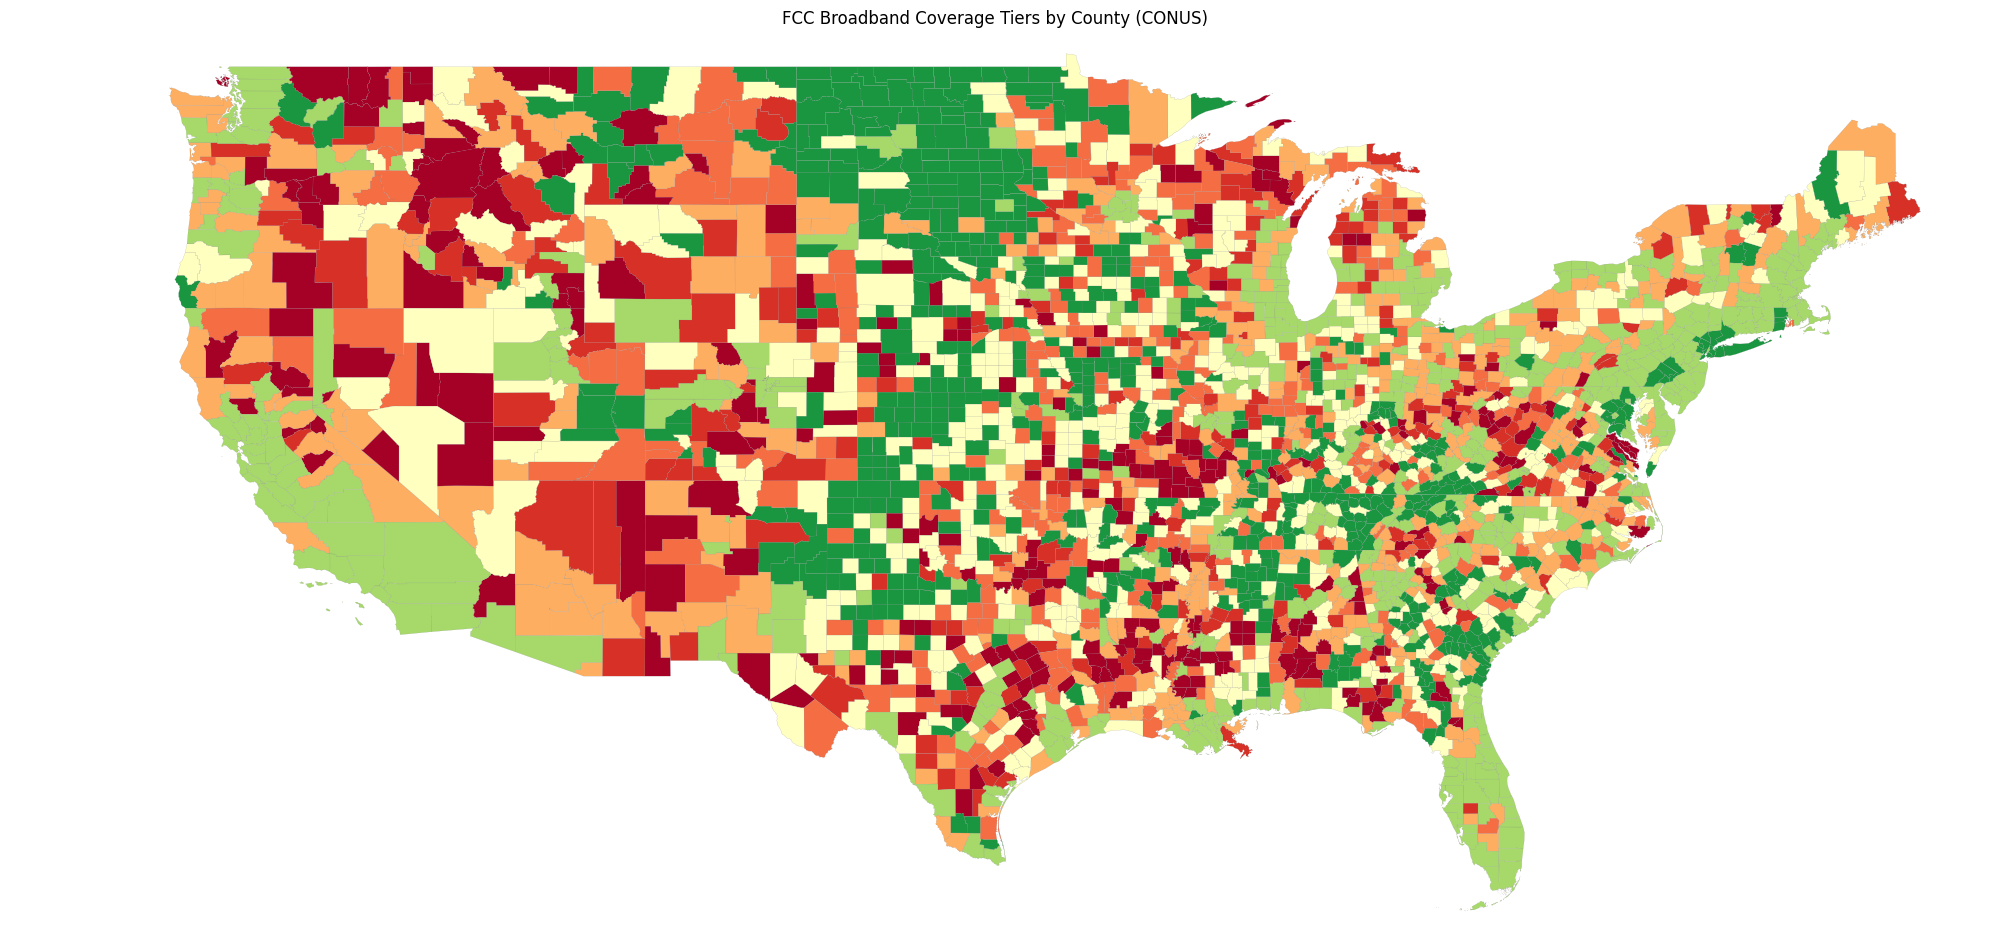

In [21]:
# Plot
fig, ax = plt.subplots(1, 1, figsize=(20, 12))
counties_merged.plot(
    column="tier",
    categorical=True,
    color=counties_merged["tier"].map(TIER_COLORS),
    legend=True,
    ax=ax,
    linewidth=0.1,
    edgecolor="gray",
)
ax.set_xlim(-130, -65)
ax.set_ylim(24, 50)
ax.set_axis_off()
ax.set_title("FCC Broadband Coverage Tiers by County (CONUS)")
plt.tight_layout()
plt.show()

In [19]:
# Validate specific counties against FCC website (all show 100% at >=100/20)
validate_ids = [
    "38001", 
    "72007", 
    "72013", 
    "13005", 
    "21007", 
    "38003", 
    "38005", 
    "38007", 
    "38009", 
    "38011"]

check = counties[counties["geography_id"].isin(validate_ids)].copy()

display_cols = [
    "geography_desc", "geography_id", "total_units", "tier",
    "fiber_speed_100_20", "cable_speed_100_20", "copper_speed_100_20",
    "fiber_100_20", "any_tech_100_20",
]
check[display_cols].sort_values("geography_id")

,geography_desc,geography_id,total_units,tier,fiber_speed_100_20,cable_speed_100_20,copper_speed_100_20,fiber_100_20,any_tech_100_20
394,Bacon County,13005,5653,A: Fiber ≥80%,1.000000,0.601981,0.0,1.000000,1.000000
1002,Ballard County,21007,4582,A: Fiber ≥80%,1.000000,0.402444,0.0,1.000000,1.000000
1763,Adams County,38001,1794,A: Fiber ≥80%,1.000000,0.593088,0.0,1.000000,1.000000
1764,Barnes County,38003,6932,A: Fiber ≥80%,0.999711,0.019475,0.0,0.999711,0.999711
1765,Benson County,38005,3954,A: Fiber ≥80%,1.000000,0.000000,0.0,1.000000,1.000000
1766,Billings County,38007,976,A: Fiber ≥80%,1.000000,0.000000,0.0,1.000000,1.000000
1767,Bottineau County,38009,5663,A: Fiber ≥80%,1.000000,0.288893,0.0,1.000000,1.000000
1768,Bowman County,38011,2356,A: Fiber ≥80%,1.000000,0.595925,0.0,1.000000,1.000000
2323,Aguas Buenas Municipio,72007,8075,C: Fiber 60–80%,0.753932,0.590836,0.0,0.753932,0.753932
2326,Arecibo Municipio,72013,37557,A: Fiber ≥80%,0.876721,0.908912,0.0,0.876721,0.908912
